# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
 



## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [2]:
df = pd.read_csv('../data/am_pm.csv')

In [3]:
def plot_decision_boundary(model, X, scaler=None):
    ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500), 
        np.linspace(y_min, y_max, 500)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    if scaler:
        grid_for_pred = scaler.transform(grid)
    else:
        grid_for_pred = grid

    Z = model.predict(grid_for_pred)
    
    if isinstance(Z[0], str):
        Z = np.where(Z == 'working_day', 0, 1)
    
    Z = Z.reshape(xx.shape)
    
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

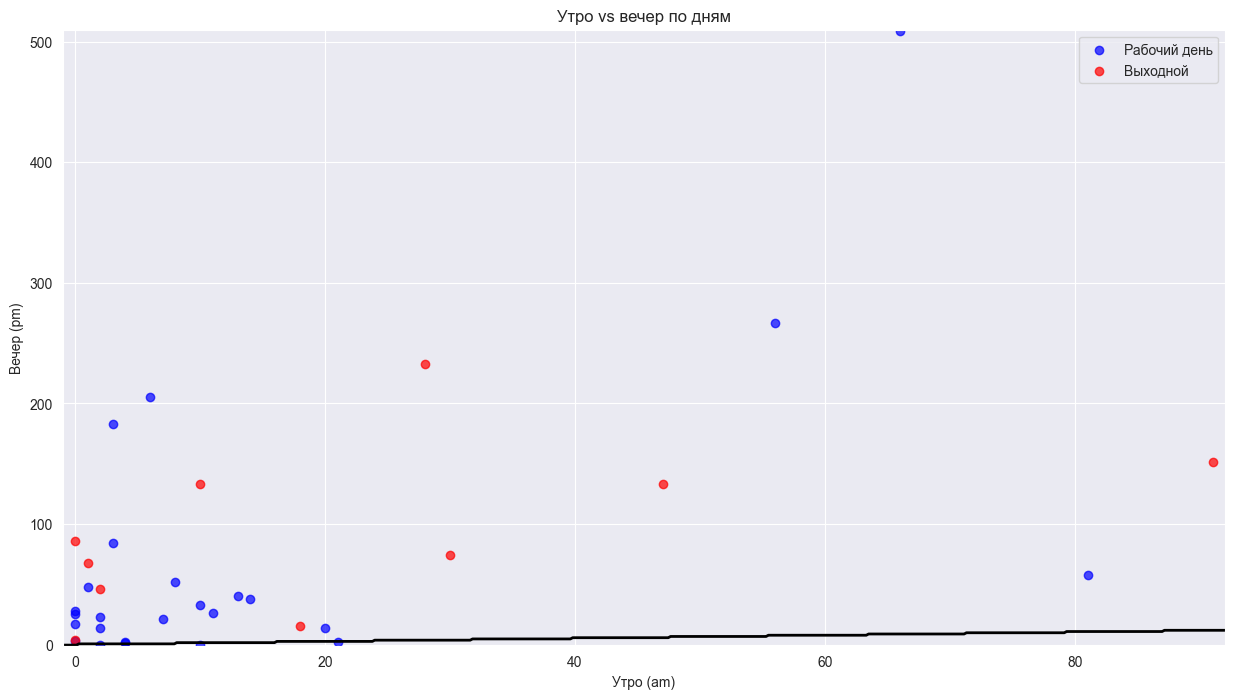

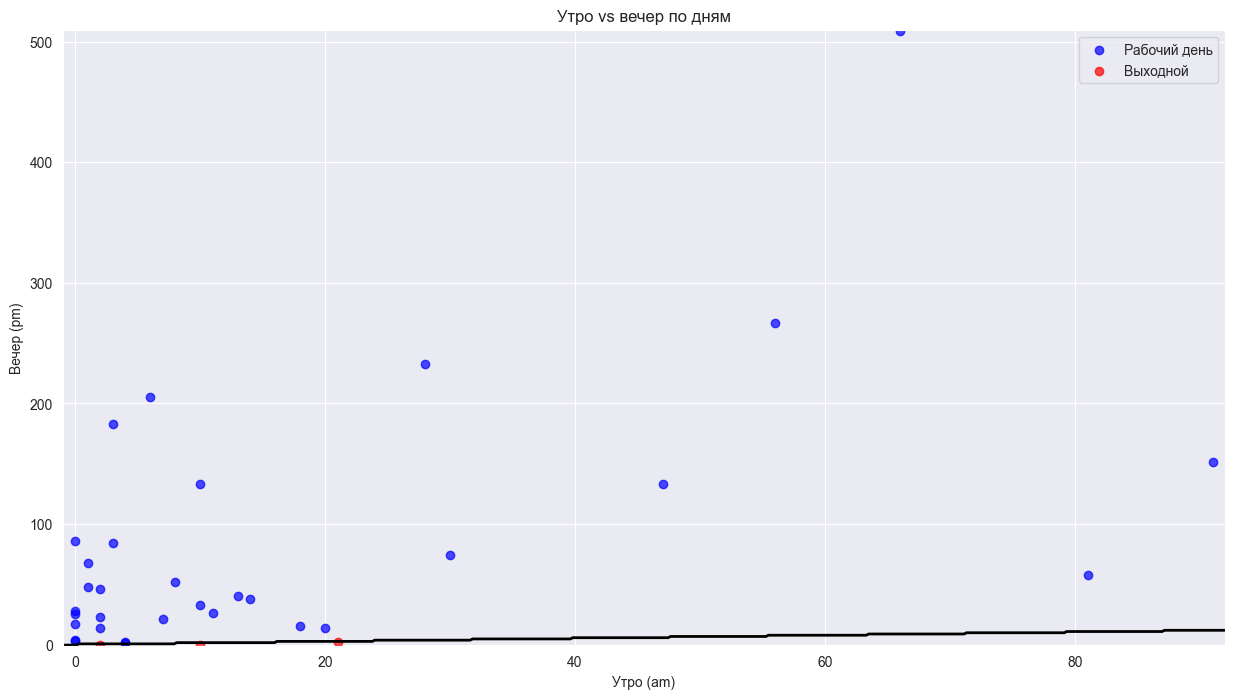

In [4]:

model = LogisticRegression(
    random_state=21,
    fit_intercept=False
)
X = df[['am', 'pm']].values
y = np.where(df['target'] == 'working_day', 0, 1)
model.fit(X, y)
y_pred = model.predict(X)
df_pred = df.copy()
df_pred['predict'] = np.where(y_pred == 1, 'weekend', 'working_day')

plt.figure(figsize=(15, 8))

work = df[df['target'] == 'working_day']
plt.scatter(work['am'], work['pm'], color='blue', label='Рабочий день', alpha=0.7)

week = df[df['target'] == 'weekend']
plt.scatter(week['am'], week['pm'], color='red', label='Выходной', alpha=0.7)
plot_decision_boundary(model, X)
plt.xlabel('Утро (am)')
plt.ylabel('Вечер (pm)')
plt.title('Утро vs вечер по дням')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 8))

work = df_pred[df_pred['predict'] == 'working_day']
plt.scatter(work['am'], work['pm'], color='blue', label='Рабочий день', alpha=0.7)

week = df_pred[df_pred['predict'] == 'weekend']
plt.scatter(week['am'], week['pm'], color='red', label='Выходной', alpha=0.7)
plot_decision_boundary(model, X)

plt.xlabel('Утро (am)')
plt.ylabel('Вечер (pm)')
plt.title('Утро vs вечер по дням')
plt.legend()
plt.grid(True)
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [5]:
scaler = StandardScaler()

In [6]:
scaled_X = scaler.fit_transform(X)

model.fit(scaled_X, y)
y_scaled_pred = model.predict(scaled_X)
df_scaled_pred = df.copy()
df_scaled_pred['predict'] = np.where(y_scaled_pred == 1, 'weekend', 'working_day')
df_scaled_pred

,date,target,am,pm,predict
0,2020-04-17,working_day,21,2,working_day
1,2020-04-18,weekend,1,68,working_day
2,2020-04-19,weekend,18,15,working_day
3,2020-04-20,working_day,2,23,working_day
4,2020-04-21,working_day,0,25,working_day
5,2020-04-22,working_day,0,28,working_day
6,2020-04-23,working_day,10,33,working_day
7,2020-04-24,working_day,2,14,working_day
8,2020-04-25,weekend,30,74,weekend
9,2020-04-26,weekend,28,233,weekend


In [7]:
y_true = df_scaled_pred['target']
y_scaled_pred = df_scaled_pred['predict']

acc_model = accuracy_score(y_true, y_scaled_pred)
print('Accuracy модели:', acc_model)
majority_class = df_scaled_pred['target'].mode()[0]
y_scaled_pred_naive = np.full_like(y_true, fill_value=majority_class)

acc_naive = accuracy_score(y_true, y_scaled_pred_naive)
print('Accuracy наивного случая:', acc_naive)

Accuracy модели: 0.7428571428571429
Accuracy наивного случая: 0.7142857142857143


Ответ: получилось лучше

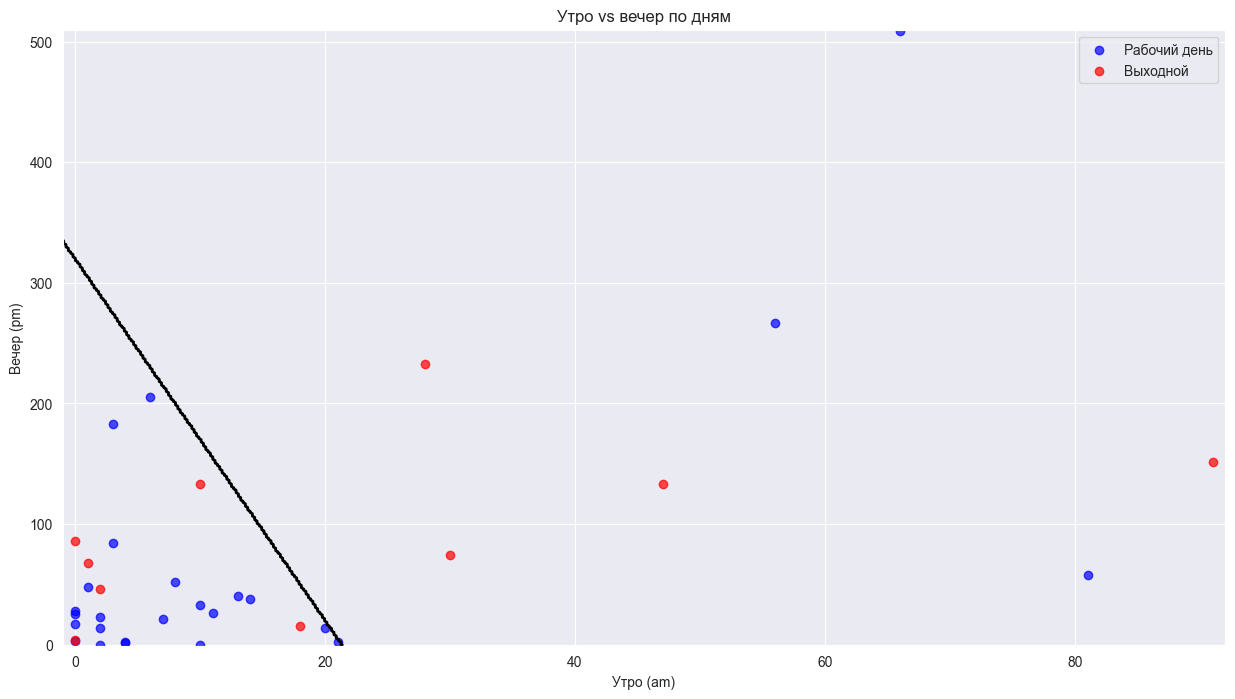

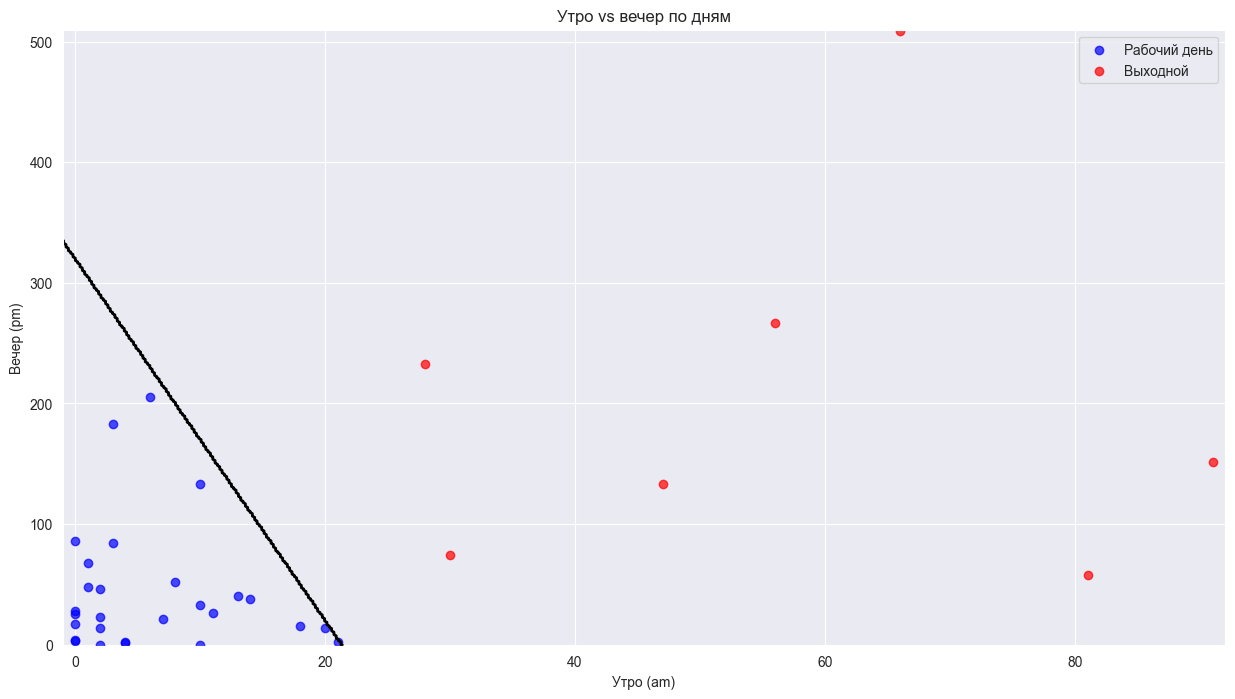

In [8]:
plt.figure(figsize=(15, 8))

work = df[df['target'] == 'working_day']
plt.scatter(work['am'], work['pm'], color='blue', label='Рабочий день', alpha=0.7)

week = df[df['target'] == 'weekend']
plt.scatter(week['am'], week['pm'], color='red', label='Выходной', alpha=0.7)
plot_decision_boundary(model, X, scaler=scaler)

plt.xlabel('Утро (am)')
plt.ylabel('Вечер (pm)')
plt.title('Утро vs вечер по дням')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 8))

work = df_scaled_pred[df_scaled_pred['predict'] == 'working_day']
plt.scatter(work['am'], work['pm'], color='blue', label='Рабочий день', alpha=0.7)

week = df_scaled_pred[df_scaled_pred['predict'] == 'weekend']
plt.scatter(week['am'], week['pm'], color='red', label='Выходной', alpha=0.7)
plot_decision_boundary(model, X, scaler=scaler)
plt.xlabel('Утро (am)')
plt.ylabel('Вечер (pm)')
plt.title('Утро vs вечер по дням')
plt.legend()
plt.grid(True)
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [9]:
X = df[['am', 'pm']].values
y = np.where(df['target'] == 'working_day', 0, 1)

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [11]:
svc = SVC(probability=True, random_state=21)
svc.fit(X_scaled, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
y_pred = svc.predict(X_scaled)
df_svc = df.copy()
df_svc['predict'] = np.where(y_pred == 1, 'weekend', 'working_day')


In [13]:
y_true = df_svc['target']
y_svc_pred = df_svc['predict']

acc_model = accuracy_score(y_true, y_svc_pred)
print('Accuracy svc модели:', acc_model)
majority_class = df_svc['target'].mode()[0]
y_pred_naive = np.full_like(y_true, fill_value=majority_class)

acc_naive = accuracy_score(y_true, y_pred_naive)
print('Accuracy наивного случая:', acc_naive)

Accuracy svc модели: 0.7428571428571429
Accuracy наивного случая: 0.7142857142857143


In [14]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
best_acc = 0
best_kernel = ''
for k in kernels:
    temp_svc = SVC(kernel=k, probability=True, random_state=21)
    temp_svc.fit(X_scaled, y)
    acc_svc = accuracy_score(y, temp_svc.predict(X_scaled))
    print(f"Для ядра {k} точность равна: {acc_svc}")
    if acc_svc > best_acc:
        best_acc = acc_svc
        best_kernel = k

print(f"best: {best_kernel} {best_acc}")

Для ядра linear точность равна: 0.7142857142857143
Для ядра rbf точность равна: 0.7428571428571429
Для ядра poly точность равна: 0.7428571428571429
Для ядра sigmoid точность равна: 0.6857142857142857
best: rbf 0.7428571428571429


In [15]:
svc_best = SVC(probability=True, random_state=21, kernel=best_kernel)
svc_best.fit(X_scaled, np.where(df['target'] == 'working_day', 0, 1))
y_pred_best = svc_best.predict(X_scaled)
df_svc_best = df.copy()
df_svc_best['predict'] = np.where(y_pred_best == 1, 'weekend', 'working_day')

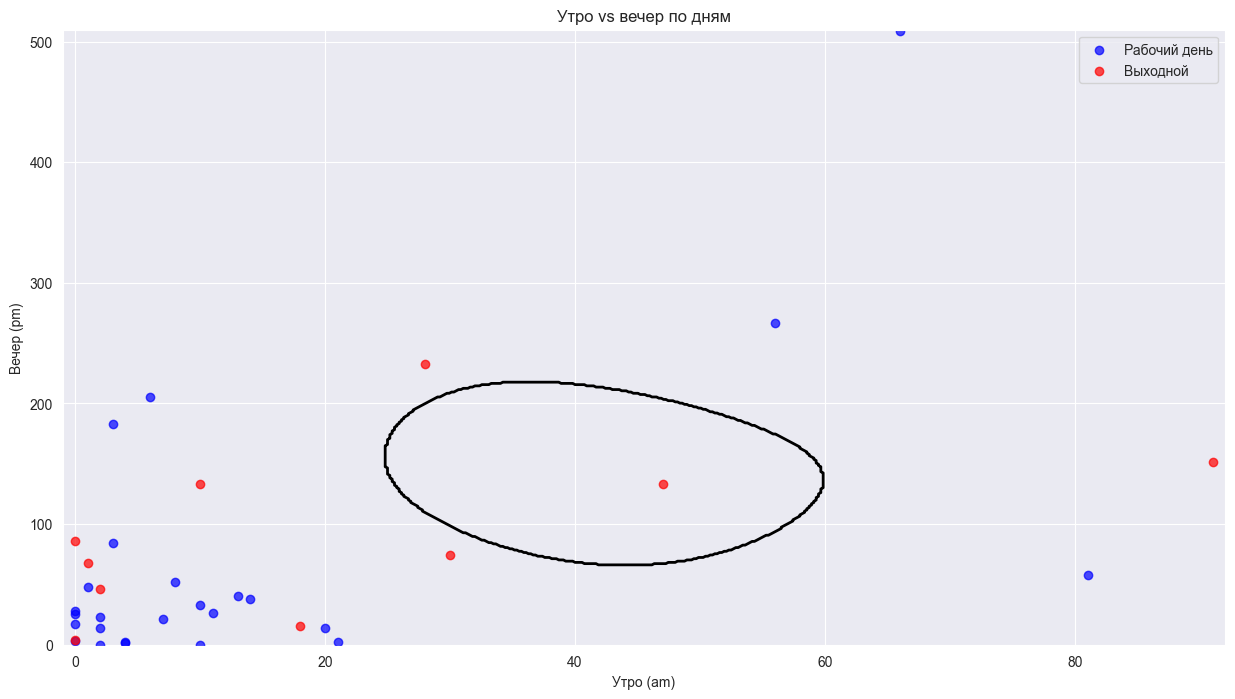

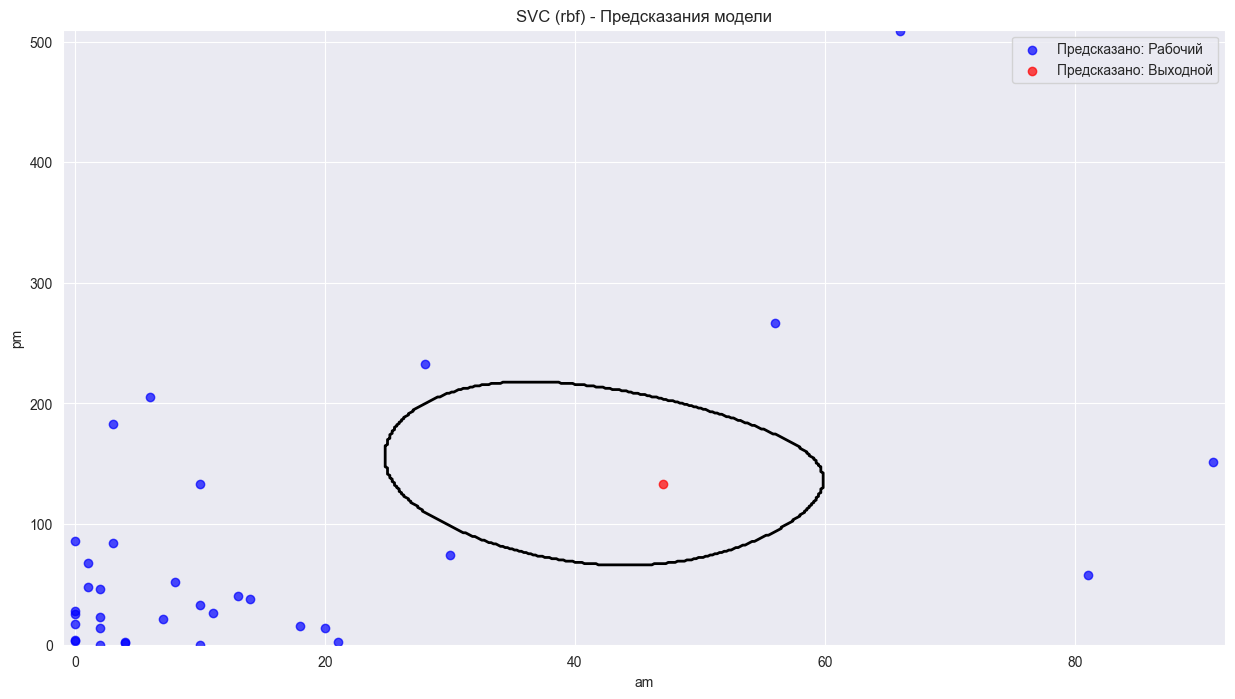

In [16]:
plt.figure(figsize=(15, 8))

work = df[df['target'] == 'working_day']
plt.scatter(work['am'], work['pm'], color='blue', label='Рабочий день', alpha=0.7)

week = df[df['target'] == 'weekend']
plt.scatter(week['am'], week['pm'], color='red', label='Выходной', alpha=0.7)
plot_decision_boundary(svc_best, X,scaler)
plt.xlabel('Утро (am)')
plt.ylabel('Вечер (pm)')
plt.title('Утро vs вечер по дням')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 8))

plt.scatter(df_svc_best[df_svc_best['predict'] == 'working_day']['am'], 
            df_svc_best[df_svc_best['predict'] == 'working_day']['pm'], 
            color='blue', label='Предсказано: Рабочий', alpha=0.7)
plt.scatter(df_svc_best[df_svc_best['predict'] == 'weekend']['am'], 
            df_svc_best[df_svc_best['predict'] == 'weekend']['pm'], 
            color='red', label='Предсказано: Выходной', alpha=0.7)
plot_decision_boundary(svc_best, X, scaler)

plt.xlabel('am')
plt.ylabel('pm')
plt.title(f'SVC ({svc_best.kernel}) - Предсказания модели')
plt.legend()
plt.grid(True)
plt.show()



## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [17]:
tree = DecisionTreeClassifier( max_depth=4, random_state=42 )

In [18]:
tree.fit(X_scaled, np.where(df['target'] == 'working_day', 0, 1))

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [19]:
y_tree_pred = tree.predict(X_scaled)
df_tree_pred = df.copy()
df_tree_pred['predict'] = np.where(y_tree_pred == 1, 'weekend', 'working_day')

In [20]:
y_true = df_tree_pred['target']
y_tree_pred = np.where(y_tree_pred == 1, 'weekend', 'working_day')
acc_tree = accuracy_score(y_true, y_tree_pred)
print(f"for max_depth = 4: {acc_tree}")

for max_depth = 4: 0.9428571428571428


In [21]:
tree_md5 = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_md5.fit(X_scaled, np.where(df['target'] == 'working_day', 0, 1))
y_tree_pred_md5 = tree_md5.predict(X_scaled)
df_tree_pred_md5 = df.copy()
df_tree_pred_md5['predict'] = np.where(y_tree_pred_md5 == 1, 'weekend', 'working_day')
y_true = df_tree_pred_md5['target']
y_tree_pred_md5 = np.where(y_tree_pred_md5 == 1, 'weekend', 'working_day')
acc_tree = accuracy_score(y_true, y_tree_pred_md5)
print(f"for max_depth = 5: {acc_tree}")

for max_depth = 5: 0.9714285714285714


In [22]:
tree_md6 = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_md6.fit(X_scaled, np.where(df['target'] == 'working_day', 0, 1))
y_tree_pred_md6 = tree_md6.predict(X_scaled)
df_tree_pred_md6 = df.copy()
df_tree_pred_md6['predict'] = np.where(y_tree_pred_md6 == 1, 'weekend', 'working_day')
y_true = df_tree_pred_md6['target']
y_tree_pred_md6 = np.where(y_tree_pred_md6 == 1, 'weekend', 'working_day')
acc_tree = accuracy_score(y_true, y_tree_pred_md6)
print(f"for max_depth = 6: {acc_tree}")

for max_depth = 6: 1.0


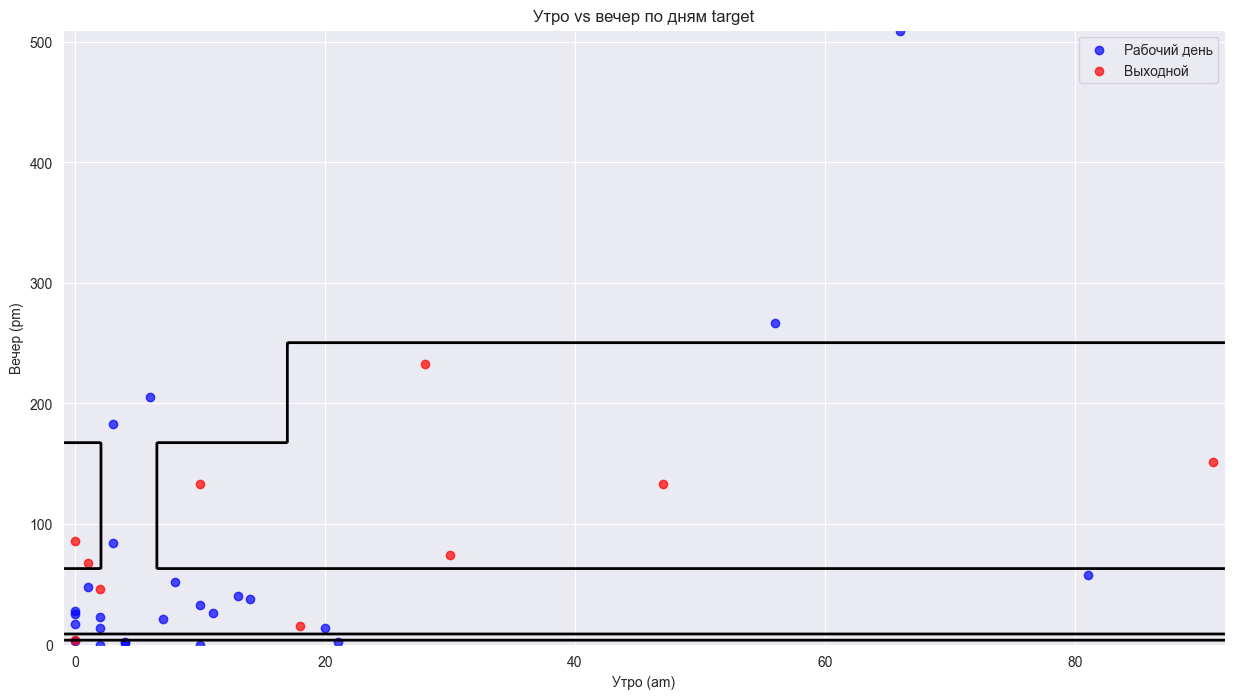

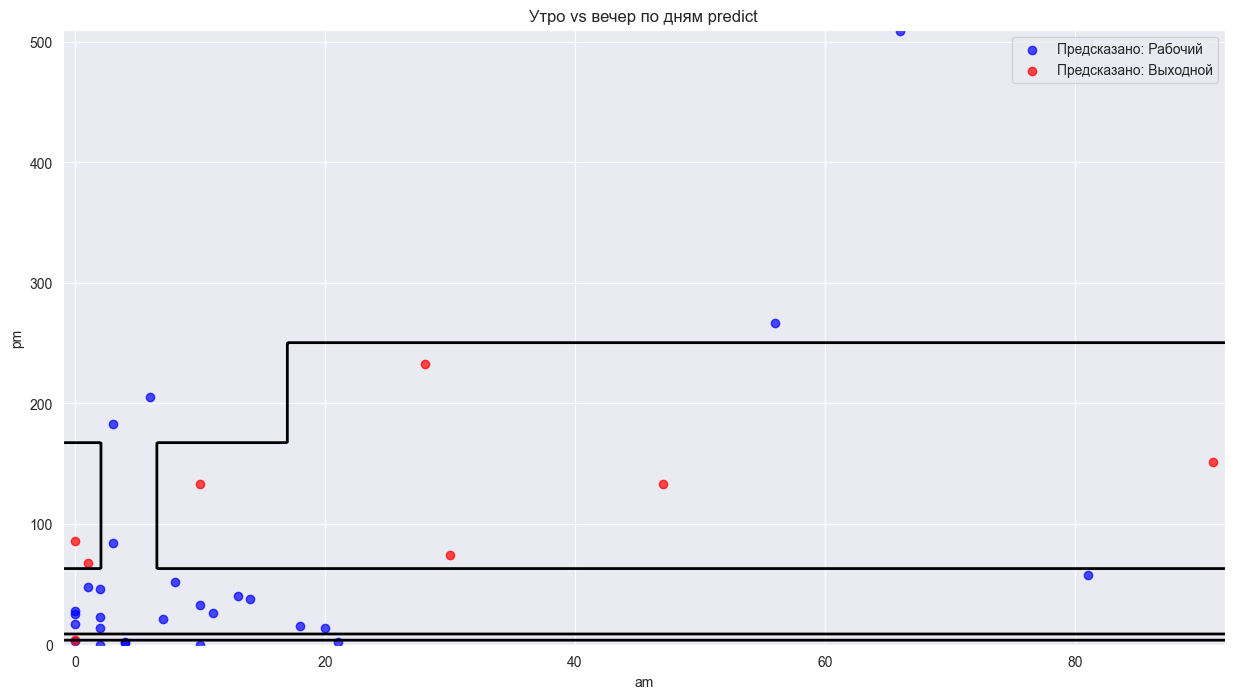

In [23]:
plt.figure(figsize=(15, 8))

work = df[df['target'] == 'working_day']
plt.scatter(work['am'], work['pm'], color='blue', label='Рабочий день', alpha=0.7)

week = df[df['target'] == 'weekend']
plt.scatter(week['am'], week['pm'], color='red', label='Выходной', alpha=0.7)
plot_decision_boundary(tree, X,scaler)
plt.xlabel('Утро (am)')
plt.ylabel('Вечер (pm)')
plt.title('Утро vs вечер по дням target')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 8))

plt.scatter(df_tree_pred[df_tree_pred['predict'] == 'working_day']['am'], 
            df_tree_pred[df_tree_pred['predict'] == 'working_day']['pm'], 
            color='blue', label='Предсказано: Рабочий', alpha=0.7)
plt.scatter(df_tree_pred[df_tree_pred['predict'] == 'weekend']['am'], 
            df_tree_pred[df_tree_pred['predict'] == 'weekend']['pm'], 
            color='red', label='Предсказано: Выходной', alpha=0.7)
plot_decision_boundary(tree, X,scaler)

plt.xlabel('am')
plt.ylabel('pm')
plt.title('Утро vs вечер по дням predict')

plt.legend()
plt.grid(True)
plt.show()



[Text(0.40625, 0.9, 'x[1] <= -0.121\ngini = 0.408\nsamples = 35\nvalue = [25, 10]'),
 Text(0.125, 0.7, 'x[1] <= -0.705\ngini = 0.227\nsamples = 23\nvalue = [20, 3]'),
 Text(0.265625, 0.8, 'True  '),
 Text(0.0625, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.1875, 0.5, 'x[1] <= -0.651\ngini = 0.291\nsamples = 17\nvalue = [14, 3]'),
 Text(0.125, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.3, 'x[0] <= -0.013\ngini = 0.219\nsamples = 16\nvalue = [14, 2]'),
 Text(0.1875, 0.1, 'gini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.3125, 0.1, 'gini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.6875, 0.7, 'x[1] <= 0.9\ngini = 0.486\nsamples = 12\nvalue = [5, 7]'),
 Text(0.546875, 0.8, '  False'),
 Text(0.5625, 0.5, 'x[0] <= -0.42\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.5, 0.3, 'x[0] <= -0.613\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.4375, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5625, 0.1, 'gini = 0.0\nsamples = 1\nva

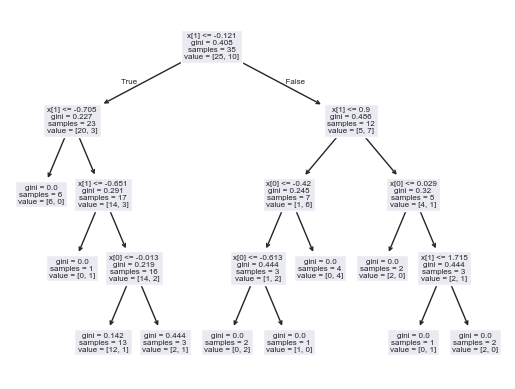

In [24]:
plot_tree(tree)

Ответ: 6